In [39]:
import os
import json
import glob
import shutil
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import re

_PAPER_RC = {
    "figure.dpi": 220,
    "savefig.dpi": 320,
    "font.size": 12.0,
    "axes.titlesize": 14,
    "axes.labelsize": 12.5,
    "legend.fontsize": 11.0,
    "xtick.labelsize": 11.0,
    "ytick.labelsize": 11.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": ":",
    "grid.alpha": 0.28,
}
# Neutral palette
COL_OBS   = "#4C78A8"
COL_LOWER = "#54A24B"
COL_UPPER = "#E45756"
COL_ENV   = "#F58518"
COL_THETA = "#B279A2"
COL_QRIB  = "#333333"  # almost black


In [11]:
def _apply_style():
    """
    Apply a consistent, paper-friendly Matplotlib style via rcParams.

    This sets DPI, font sizes, spines visibility, and a light grid. It should be
    called before creating any figures to ensure consistent styling.
    """
    for k, v in _PAPER_RC.items():
        matplotlib.rcParams[k] = v


In [13]:
run_root = "out/preset_paper_full/"

_apply_style()

with open(run_root + "manifest.json", "r") as f:
    man = json.load(f)

runs = man.get("runs", [])

In [ ]:
import glob

def _edge_csv_for_tag(
        run_root: str, 
        tag: str
        ):
    """
    Return the path to the edge CSV for a given run tag, if present.

    Files are normally named {tag}_edges.csv where periods in tag are
    replaced with underscores. As a fallback, the function returns the first
    file in the directory that starts with the normalized base and ends with
    edges.csv.

    Parameters
    - run_root: Run directory that should contain CSVs.
    - tag: Identifier string for a graph/model instance.

    Returns
    - The absolute path to the CSV file if found, else None.
    """
    # run_experiments writes {base_name}_edges.csv in the run folder.
    base = tag.replace('.', '_')
    cand = os.path.join(run_root, f"{base}_edges.csv")
    if os.path.exists(cand):
        return cand
    # fallback: pick the first *edges.csv that starts with base
    gl = glob.glob(os.path.join(run_root, f"{base}*edges.csv"))
    return gl[0] if gl else None

In [15]:
run = runs[0]
run

{'tag': 'er_n800_p0.0100125',
 'n': 800,
 'm': 3234,
 'summary': {'c_OR': {'count': 3234,
   'mean': -0.9789406657218933,
   'std': 0.16387389600276947,
   'min': -1.4692307710647583,
   'q05': -1.225000023841858,
   'q25': -1.0952380895614624,
   'median': -1.0,
   'q75': -0.875,
   'q95': -0.6932070851325989,
   'max': -0.2954545319080353},
  'c_BF': {'count': 3234,
   'mean': -1.3780183792114258,
   'std': 0.18300312757492065,
   'min': -1.755555510520935,
   'q05': -1.618181824684143,
   'q25': -1.514285683631897,
   'median': -1.4141414165496826,
   'q75': -1.2698413133621216,
   'q95': -1.0285714864730835,
   'max': -0.5555555820465088},
  'env_slack': {'count': 3234,
   'mean': 0.4850911498069763,
   'std': 0.1120501160621643,
   'min': 0.11356209218502045,
   'q05': 0.3007074296474457,
   'q25': 0.40584415197372437,
   'median': 0.4858440160751343,
   'q75': 0.5617694854736328,
   'q95': 0.6666666865348816,
   'max': 0.8230769038200378},
  'theta_slack': {'count': 3234,
   'mea

In [ ]:
EXPECTED_COLS = [
    "u","v","deg_i","deg_j","triangle","Xi","sho_max",
    "c_BF","c_OR","c_OR0","Theta_const","Theta_slope","Theta_at_t","env_upper",
    "cOR_lower_from_cBF","cOR_upper_from_cBF","cBF_lower_from_cOR","cBF_upper_from_cOR",
]

def _read_edges(
        path_csv: str
        ) -> pd.DataFrame:
    """
    Read a per-edge CSV and normalize column names when possible.

    The reader is tolerant to letter-casing differences by attempting to map
    lower-cased versions of known column names back to the expected names.

    Parameters
    - path_csv: Path to the edge-level CSV file.

    Returns
    - A pandas DataFrame with original or normalized column names.
    """
    df = pd.read_csv(path_csv)
    # Be robust to lower-cased headers
    missing = [c for c in EXPECTED_COLS if c not in df.columns]
    if missing:
        lower_map = {c.lower(): c for c in df.columns}
        new_cols = {}
        for c in missing:
            if c.lower() in lower_map:
                new_cols[lower_map[c.lower()]] = c
        if new_cols:
            df = df.rename(columns=new_cols)
    return df

def _pretty_from_tag(tag: str) -> str:
    """
    Short, publication-friendly display name for a run tag.
    Examples:
      - "er_n2000_p0.01" -> "ER $n=2000$, $p=0.01$"
      - "ws_n1000_k10_b0.2" -> "WS $n=1000$, $k=10$, $\\beta=0.2$"
      - "ba_n5000_m3" -> "BA $n=5000$, $m=3$"
      - "real_karate" -> "Real: Zachary Karate"
    """
    t = tag

    # ER: er_n{n}_p{p}
    m = re.fullmatch(r"er_n(\d+)_p([0-9.]+)", t)
    if m:
        n, p = m.groups()
        return rf"ER $n={int(n)}$, $p={p}$"

    # WS: ws_n{n}_k{k}_b{beta}
    m = re.fullmatch(r"ws_n(\d+)_k(\d+)_b([0-9.]+)", t)
    if m:
        n, k, b = m.groups()
        return rf"WS $n={int(n)}$, $k={int(k)}$, $\beta={b}$"

    # BA: ba_n{n}_m{m}
    m = re.fullmatch(r"ba_n(\d+)_m(\d+)", t)
    if m:
        n, m2 = m.groups()
        return rf"BA $n={int(n)}$, $m={int(m2)}$"

    # RG: rg_n{n}_r{r}
    m = re.fullmatch(r"rg_n(\d+)_r([0-9.]+)", t)
    if m:
        n, r = m.groups()
        return rf"RG $n={int(n)}$, $r={r}$"


    # 2-block SBM: sbm2_n{n}_pin{p_in}_pout{p_out}
    m = re.fullmatch(r"sbm2_n(\d+)_pin([0-9.]+)_pout([0-9.]+)", t)
    if m:
        n, pin, pout = m.groups()
        return rf"SBM2 $n={int(n)}$, $p_{{\mathrm{{in}}}}={pin}$, $p_{{\mathrm{{out}}}}={pout}$"

    # HRG: hrg_n{n}_R{R}_a{alpha}_T{T}
    m = re.fullmatch(r"hrg_n(\d+)_R([0-9.]+)_a([0-9.]+)_T([0-9.]+)", t)
    if m:
        n, R, a, T = m.groups()
        return rf"HRG $n={int(n)}$, $R={R}$, $\alpha={a}$, $T={T}$"

    # Canonical families
    m = re.fullmatch(r"cycle_n(\d+)", t)
    if m:
        (n,) = m.groups()
        return rf"Cycle $C_{{{int(n)}}}$"

    m = re.fullmatch(r"torus_(\d+)x(\d+)", t)
    if m:
        m1, n1 = m.groups()
        return rf"Torus $C_{{{int(m1)}}}\times C_{{{int(n1)}}}$"
    m = re.fullmatch(r"torus_(\d+)x(\d+)_edges", t)
    if m:
        m1, n1 = m.groups()
        return rf"Torus $C_{{{int(m1)}}}\times C_{{{int(n1)}}}$"

    m = re.fullmatch(r"rreg_n(\d+)_d(\d+)", t)
    if m:
        n, d = m.groups()
        return rf"d-Reg $n={int(n)}$, $d={int(d)}$"

    m = re.fullmatch(r"grid_(\d+)x(\d+)", t)
    if m:
        m1, n1 = m.groups()
        return rf"Grid ${{{int(m1)}\times {int(n1)}}}$"

    m = re.fullmatch(r"grid_(\d+)x(\d+)_edges", t)
    if m:
        m1, n1 = m.groups()
        return rf"Grid ${{{int(m1)}\times {int(n1)}}}$"

    m = re.fullmatch(r"tree_d(\d+)_h(\d+)", t)
    if m:
        d, h = m.groups()
        return rf"{int(d)}-ary Tree ($h={int(h)}$)"

    m = re.fullmatch(r"complete_n(\d+)", t)
    if m:
        (n,) = m.groups()
        return rf"Complete $K_{{{int(n)}}}$"

    # Real networks (remove/avoid Wikipedia mention)
    m = re.fullmatch(r"real_(.+)", t)
    if m:
        name = m.group(1)
        # Any 'wiki' variant maps to a generic label; no Wikipedia mention
        if re.search(r"wiki", name, flags=re.IGNORECASE):
            return "Real network"

        pretty_map = {
            "karate": "Zachary Karate",
            "jazz": "Jazz Musicians",
            "power_grid": "US Power Grid",
            "yeast": "Yeast TF",
            "arxiv": "arXiv hep-ph citations",
        }
        return f"Real: {pretty_map.get(name, name.replace('_', ' '))}"

    # Fallback
    return t

In [21]:
def _binned_quantiles(
        x: np.ndarray, 
        y: np.ndarray, 
        nbins: int = 28,
        qs=(0.1, 0.5, 0.9)
        ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute per-bin quantiles of y after binning by x.

    This function masks non-finite values, bins x into nbins equal-width
    bins (or a single tiny bin in degenerate cases), and computes quantiles of
    y in each bin. If no data remain after masking, it returns four empty
    arrays to simplify downstream handling.

    Parameters
    - x: Values to bin on (e.g., c_BF).
    - y: Values whose quantiles are computed per bin (e.g., c_OR).
    - nbins: Target number of bins.
    - qs: Quantiles to compute per bin.

    Returns
    - (centers, qL, qM, qH): Bin centers and the requested lower/median/upper
      quantiles arrays (NaN for bins with no data).
    """
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) == 0:
        # No data: return empty arrays consistently
        return (np.array([]),) * 4

    lo, hi = float(np.min(x)), float(np.max(x))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        # Degenerate: single bin
        bins = np.array([lo, lo + 1e-6])
    else:
        bins = np.linspace(lo, hi, nbins + 1)

    nb = len(bins) - 1                 # <-- ACTUAL number of bins
    idx = np.clip(np.digitize(x, bins) - 1, 0, nb - 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    qL = np.full(nb, np.nan)
    qM = np.full(nb, np.nan)
    qH = np.full(nb, np.nan)
    for b in range(nb):
        vals = y[idx == b]
        if len(vals) > 0:
            qL[b], qM[b], qH[b] = np.quantile(vals, qs)

    return centers, qL, qM, qH


In [ ]:
DISPLAY = {
    "c_OR":    r"$\mathfrak{c}_{\mathrm{OR}}$",
    "c_BF":    r"$\mathfrak{c}_{\mathrm{BF}}$",
    "c_OR0":   r"$\mathfrak{c}_{\mathrm{OR\text{-}0}}$",
    "Theta_at_t": r"$\Theta_\alpha(\triangle)$",
    "env_upper":  r"transport envelope (upper)",
}

def _hist_with_bands(
        ax: plt.Axes, 
        obs: np.ndarray,
        lower: Optional[np.ndarray] = None,
        upper: Optional[np.ndarray] = None,
        env: Optional[np.ndarray] = None,
        theta: Optional[np.ndarray] = None,
        lower_label: Optional[str] = None,
        upper_label: Optional[str] = None,
        bins: int = 60,
        title: str = "", 
        xlabel: str = ""
        ) -> None:
    """
    Plot a histogram of observed values with optional overlay distributions.

    Parameters
    - ax: A Matplotlib Axes to draw on.
    - obs: Observed values (e.g., edgewise c_OR or c_BF).
    - lower, upper: Optional arrays for lower/upper transfer distributions
      (e.g., BF->OR or OR->BF bounds per edge). Each is plotted as a step outline.
    - env: Optional transport envelope values (edgewise) drawn as a step outline.
    - theta: Optional Theta-at-t values (edgewise) drawn as a step outline.
    - lower_label, upper_label: Legend labels for the overlay distributions.
    - bins: Number of histogram bins.
    - title: Axes title.
    - xlabel: X-axis label.
    """
    # Observed distribution
    ax.hist(obs, bins=bins, density=True, alpha=0.55, color=COL_OBS, label="Observed")
    # Lower/upper transfer distributions (edgewise)
    if lower is not None and len(lower) > 0:
        ax.hist(lower, bins=bins, density=True, histtype="step", linewidth=1.6, color=COL_LOWER,
                label=(lower_label or "L. Transfer Dist."))
    if upper is not None and len(upper) > 0:
        ax.hist(upper, bins=bins, density=True, histtype="step", linewidth=1.6, color=COL_UPPER,
                label=(upper_label or "U. Transfer Dist."))
    # Envelope / Theta distributions
    if env is not None and len(env) > 0:
        ax.hist(env, bins=bins, density=True, histtype="step", linewidth=1.3, color=COL_ENV, alpha=0.6,
                label="Transport Envelope Dist.")
    if theta is not None and len(theta) > 0:
        ax.hist(theta, bins=bins, density=True, histtype="step", linewidth=1.1, color=COL_THETA, alpha=0.6,
                label=DISPLAY["Theta_at_t"] + " Dist.")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.grid(True)
    ax.legend(frameon=False, ncol=1, handlelength=1.0, handletextpad=0.5,
                loc='best')

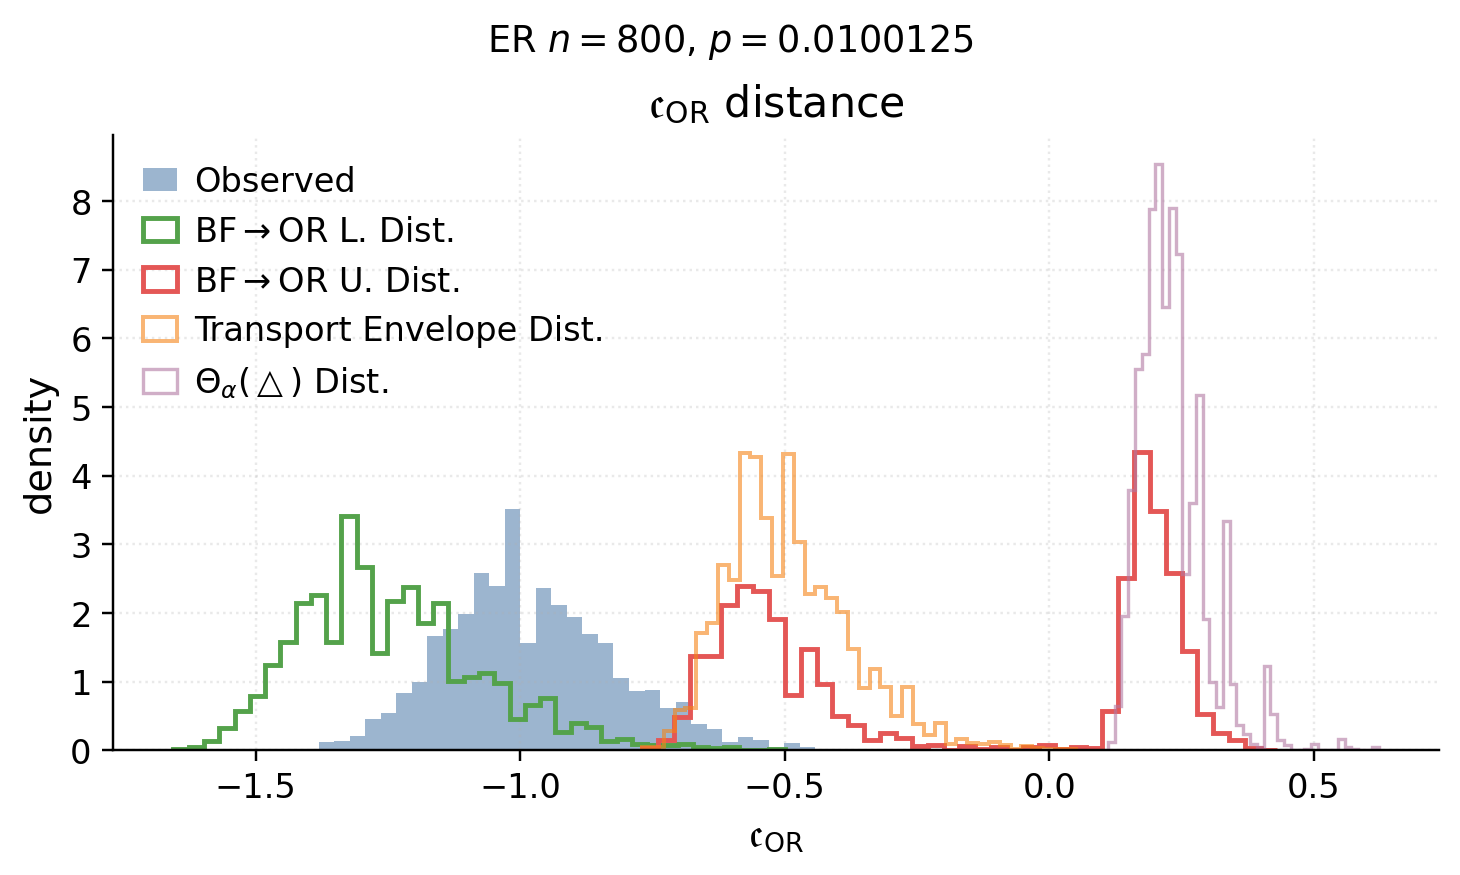

In [135]:
tag = run.get("tag") or run.get("name") or "run"
pretty = run.get("title") or run.get("pretty")  # optional pretty name in manifest
bins = 40

csv_path = _edge_csv_for_tag(run_root, tag)

df = _read_edges(csv_path)

as_np = lambda name: pd.to_numeric(df[name], errors="coerce").to_numpy() if name in df.columns else None

cOR     = as_np("c_OR")
cBF     = as_np("c_BF")
cOR_lo  = as_np("cOR_lower_from_cBF")
cOR_up  = as_np("cOR_upper_from_cBF")
cBF_lo  = as_np("cBF_lower_from_cOR")
cBF_up  = as_np("cBF_upper_from_cOR")
env_up  = as_np("env_upper")
theta_t = as_np("Theta_at_t")

fig_dir = os.path.join(run_root, "figures_paper")
safe_tag = tag.replace("/", "-").replace(" ", "_").replace(".", "_")
pretty_tag = pretty or _pretty_from_tag(tag)

# 1) OR histogram (short title; run name as suptitle)
if cOR is not None:
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    _hist_with_bands(ax, obs=cOR, lower=cOR_lo, upper=cOR_up, env=env_up, theta=theta_t,
                        lower_label=r"BF$\rightarrow$OR L. Dist.", upper_label=r"BF$\rightarrow$OR U. Dist.",
                        bins=bins, title=DISPLAY['c_OR'] + r" distance", xlabel=DISPLAY["c_OR"])
    fig.suptitle(pretty_tag, y=0.90, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)

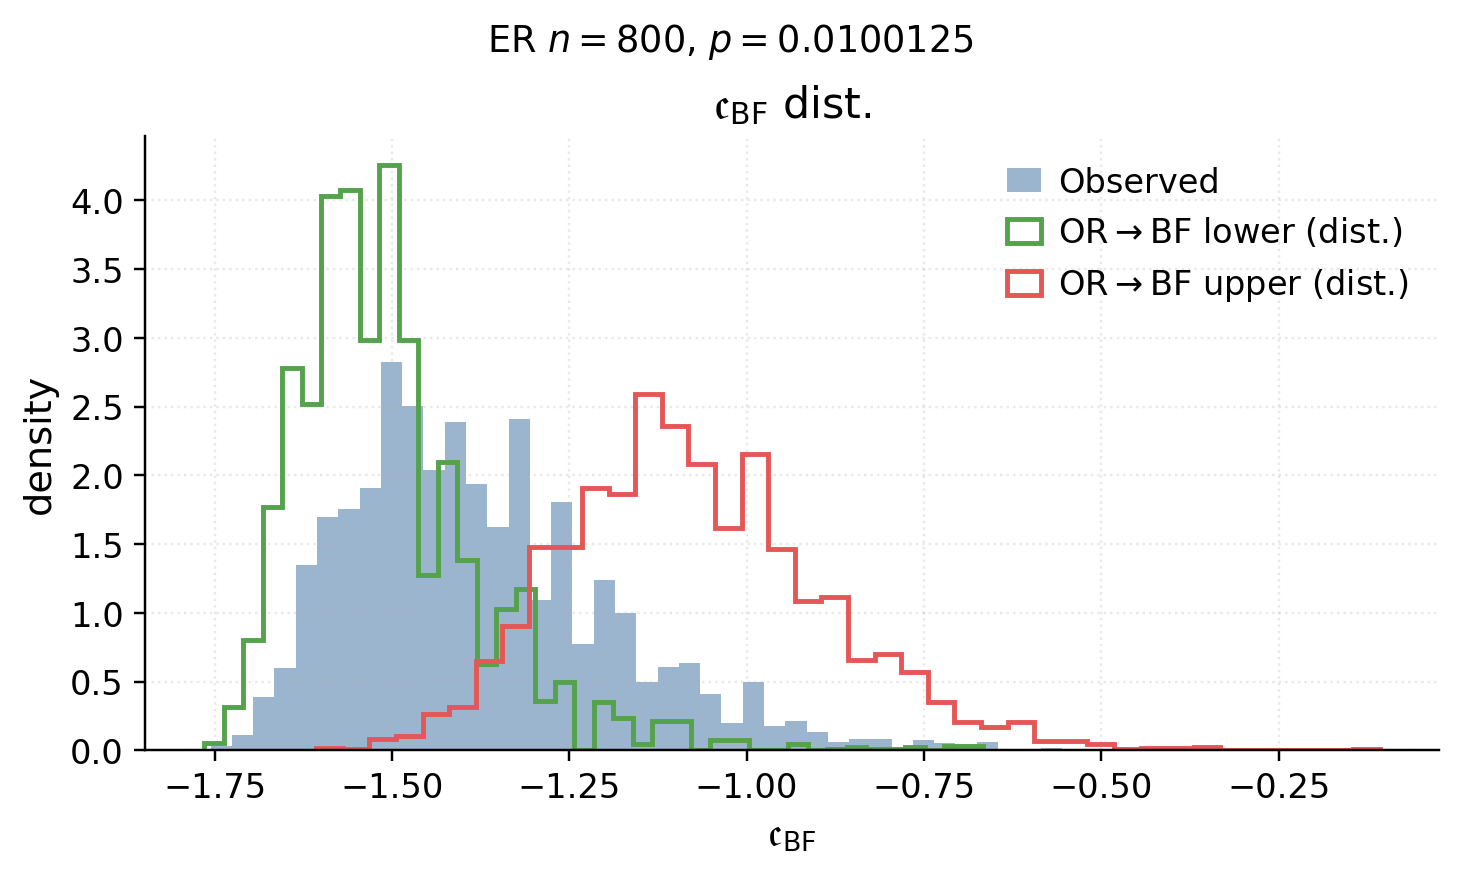

In [122]:
# 2) BF histogram (short title; run name as suptitle)
if cBF is not None:
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    _hist_with_bands(ax, obs=cBF, lower=cBF_lo, upper=cBF_up, env=None, theta=None,
                        lower_label=r"OR$\rightarrow$BF lower (dist.)", upper_label=r"OR$\rightarrow$BF upper (dist.)",
                        bins=bins, title=DISPLAY['c_BF'] + r" dist.", xlabel=DISPLAY["c_BF"])
    fig.suptitle(pretty_tag, y=0.9, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)

In [131]:
def _scatter_ribbon(ax: plt.Axes,
                    bf: np.ndarray, 
                    orv: np.ndarray,
                    lower_from_bf: Optional[np.ndarray] = None,
                    upper_from_bf: Optional[np.ndarray] = None,
                    nbins: int = 28
                    ) -> None:
    """
    Scatter plot of bf vs or with an observed quantile ribbon.

    The function optionally overlays the median of the predicted lower and/or
    upper transfer (BF->OR) after binning by bf. If the dataset is very large, a
    fixed-size random subsample is used for the scatter for clarity.

    Parameters
    - ax: A Matplotlib Axes to draw on.
    - bf: Edgewise Balanced Forman curvature values.
    - orv: Edgewise Ollivier--Ricci curvature values.
    - lower_from_bf: Optional edgewise BF->OR lower transfer predictions.
    - upper_from_bf: Optional edgewise BF->OR upper transfer predictions.
    - nbins: Number of bins to use for computing the quantile ribbon.
    """
    # Subsample if large for visual clarity
    n = len(bf)
    if n > 25000:
        rng = np.random.default_rng(1234)
        sel = rng.choice(n, size=25000, replace=False)
        bf_s, or_s = bf[sel], orv[sel]
        low_s = lower_from_bf[sel] if lower_from_bf is not None else None
    else:
        bf_s, or_s, low_s = bf, orv, lower_from_bf

    ax.scatter(bf_s, or_s, s=6, alpha=0.28, color=COL_OBS, linewidth=0, label="Edges (sample)")
    # Observed quantile ribbon of OR|BF
    xc, qL, qM, qH = _binned_quantiles(bf, orv, nbins=nbins)
    if len(xc) > 0:
        ax.plot(xc, qM, color=COL_QRIB, linewidth=1.7, label=r"Median $\mathfrak{c}_{\mathrm{OR}}\mid \mathfrak{c}_{\mathrm{BF}}$")
        ax.plot(xc, qL, color=COL_QRIB, linewidth=1.1, linestyle="--")
        ax.plot(xc, qH, color=COL_QRIB, linewidth=1.1, linestyle="--")
    # Predicted BF->OR lower (median per bin)
    if low_s is not None:
        _, _, pM, _ = _binned_quantiles(bf, lower_from_bf, nbins=nbins, qs=(0.5, 0.5, 0.5))
        ax.plot(xc, pM, color=COL_LOWER, linewidth=1.8, linestyle="-.",
                label=r"L. Transfer (BF$\rightarrow$OR): median")
    # Predicted BF->OR upper (median per bin)
    if upper_from_bf is not None:
        _, _, pM_up, _ = _binned_quantiles(bf, upper_from_bf, nbins=nbins, qs=(0.5, 0.5, 0.5))
        ax.plot(xc, pM_up, color=COL_UPPER, linewidth=1.8, linestyle="--",
                label=r"U. Transfer (BF$\rightarrow$OR): median")
    ax.set_title(r"Comparison $\mathfrak{c}_{\mathrm{BF}}$, $\mathfrak{c}_{\mathrm{OR}}$")
    ax.set_xlabel(DISPLAY["c_BF"])
    ax.set_ylabel(DISPLAY["c_OR"])
    ax.grid(True)
    ax.legend(frameon=False, ncol=1, handlelength=1.0, handletextpad=0.5,
                loc='best')

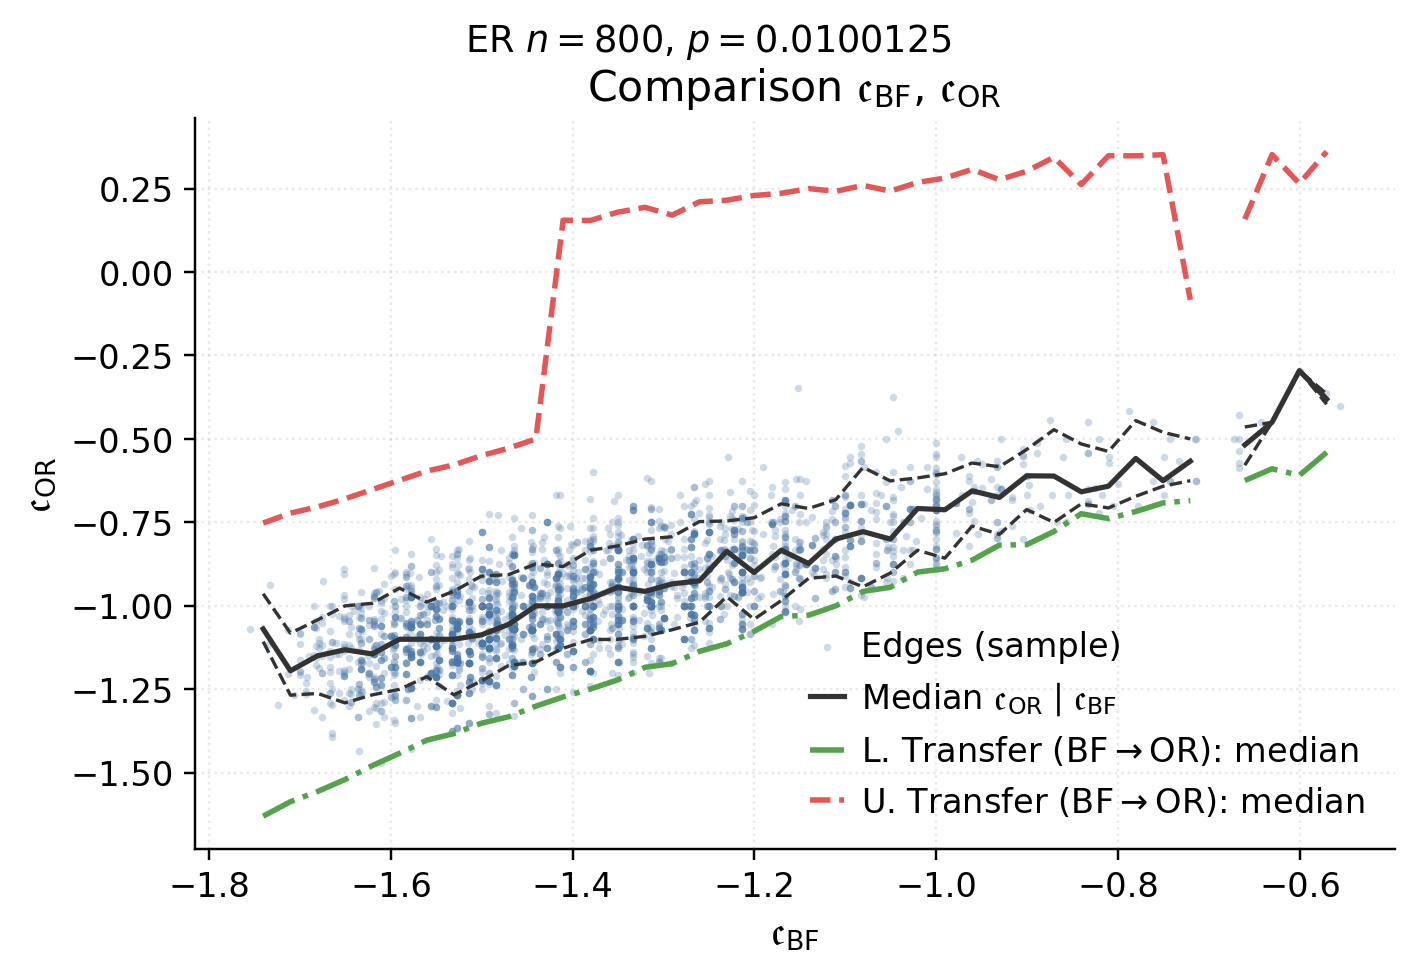

In [132]:
# 3) Scatter BF vs OR (short title already set inside helper; keep short suptitle)
if (cBF is not None) and (cOR is not None):
    fig, ax = plt.subplots(figsize=(6.6, 4.9))
    _scatter_ribbon(ax, cBF, cOR, lower_from_bf=cOR_lo, upper_from_bf=cOR_up, nbins=bins)
    fig.suptitle(pretty_tag, y=0.9, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    plt.close(fig)